In [1]:
import pynucastro as pyna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#%matplotlib widget

Figure 1. Heatings

In [2]:
time=np.exp(np.linspace(0,17.58,1000))
time_days=time/(24*3600)
'''Multicomponent Semi-analytical model'''
#termalization Barnes 2016
a_th=0.27
b_th=0.1
d_th=0.6
e_th=0.36*(np.exp(-a_th*time_days)+np.log(1+2*b_th*time_days**d_th)/(2*b_th*time_days**d_th))

#Korobkin 2020
E_korobkin=e_th*(4*10**18)*(0.5-(1/np.pi)*np.arctan((time_days*24*60*60-1.3)/0.11))**(1.3)

'''Analytical model Waxman'''
e_wax=2e10
beta_wax=1.3
alpha_wax=3
kappa_wax=0.2
M_wax=0.05
v_wax=0.1
t_M=1.5*(1/np.sqrt(1+2*alpha_wax))*np.sqrt((kappa_wax)*(M_wax/0.01)*(0.1/v_wax))
E_waxman=e_wax*(time_days/t_M)**(-beta_wax)

#termalization for waxman
f_vy=0.7
kappa_e=1
t_e=15*(1/np.sqrt(alpha_wax*(2+3*alpha_wax)))*np.sqrt(kappa_e*M_wax/0.01)*(0.1/v_wax)**(3/2)
f_e=(t_e/time_days)**2<1
f_e=np.zeros(len(time_days))+1-1*f_e+f_e*(t_e/time_days)**2
E_waxman_efectivo=(1-f_vy)*E_waxman*f_e

'''Semi-analytical XKN model'''

E_xkn=0.5*(10**10)*(time_days)**(-1.3)+2e10*np.exp(-time_days/1)

'''Representative simulation using Reaclib rates'''

data=pd.read_csv(r'Runs/Run_1/generated_energy.dat',skiprows=2,header=None, delim_whitespace=True)
time_sim=data[0]/(24*3600)
energy_sim=data[1]

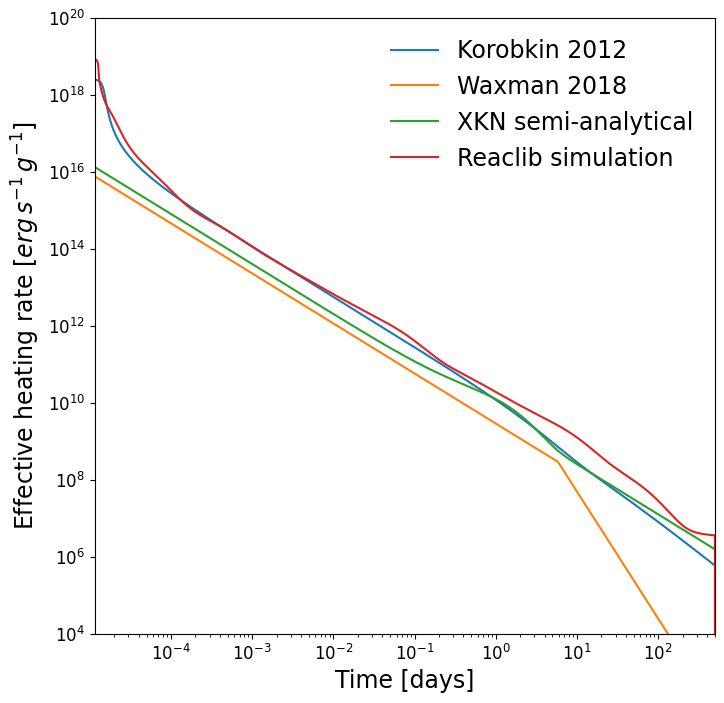

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 17,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"Effective heating rate [$erg\,s^{-1}\,g^{-1}$]")

ax.plot(time_days, E_korobkin, label="Korobkin 2012")
ax.plot(time_days, E_waxman_efectivo, label="Waxman 2018")
ax.plot(time_days, E_xkn, label="XKN semi-analytical")
ax.plot(time_sim, energy_sim, label="Reaclib simulation")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(1.1574e-5,500)
ax.set_ylim(1e4,1e20)
ax.legend(frameon=False, loc="upper right",fontsize=15, ncol=1, markerscale=5)
fig.savefig("Figure_1_Heating.pdf")

Filtros

In [4]:
filter_alpha=pyna.RateFilter(
    products=['he4'],
    exact=False,
    max_reactants=1,
    max_products=2,
    filter_function=lambda r: r.reactants[0].Z==r.products[0].Z+r.products[1].Z and r.Q>0)

filter_beta_minus=pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.reactants[0].Z==r.products[0].Z-1 and r.Q>0)

sources_exp=list(pd.read_csv('Nuclear_Data/Just_experimental/sources_exp')['0'])
filter_Experimental=pyna.RateFilter(
    filter_function=lambda r: r.source['Label'] in sources_exp)
filter_Theoretical=pyna.RateFilter(
    filter_function=lambda r: r.source['Label'] not in sources_exp)

Figura 2. Experimental data vs Reaclib and Experimental vs Empiricals

In [5]:
rates_reaclib=pyna.rates.library.Library(libfile='Nuclear_Data/Original_files/Reaclib_18_9_20')
Alpha_rates=rates_reaclib.filter(filter_alpha)
Beta_minus_rates=rates_reaclib.filter(filter_beta_minus)
Alpha_rates_exp=Alpha_rates.filter(filter_Experimental)
Alpha_rates_theo=Alpha_rates.filter(filter_Theoretical)
Beta_minus_rates_exp=Beta_minus_rates.filter(filter_Experimental)
Beta_minus_rates_theo=Beta_minus_rates.filter(filter_Theoretical)
print(f"Total alpha decay rates: {len(Alpha_rates.get_rates())}")
print(f"Experimental alpha decay rates: {len(Alpha_rates_exp.get_rates())}")
print(f"Theoretical alpha decay rates: {len(Alpha_rates_theo.get_rates())}")
print(f"Total beta minus decay rates: {len(Beta_minus_rates.get_rates())}")
print(f"Experimental beta minus decay rates: {len(Beta_minus_rates_exp.get_rates())}")
print(f"Theoretical beta minus decay rates: {len(Beta_minus_rates_theo.get_rates())}")

Total alpha decay rates: 1705
Experimental alpha decay rates: 584
Theoretical alpha decay rates: 1121
Total beta minus decay rates: 4861
Experimental beta minus decay rates: 1041
Theoretical beta minus decay rates: 3820


In [6]:
librerira=pyna.rates.library.Library(libfile='Nuclear_Data/Just_experimental/Reaclib_exp_R1')
print(len(librerira.filter(filter_beta_minus).get_rates()))

1041


In [7]:
#All alpha decay rates that have an experimental and theoretical value are listed here:
#First list is the experimental value, second list is the theoretical value.
Alpha_rates_pairs=[[],[]]
for pair in Alpha_rates.find_duplicate_links():
    if pair[0].source['Label'] in sources_exp:
        Alpha_rates_pairs[0].append(pair[0])
        Alpha_rates_pairs[1].append(pair[1])
    else:
        Alpha_rates_pairs[0].append(pair[1])
        Alpha_rates_pairs[1].append(pair[0])
print(f"Total alpha decay rates with both experimental and theoretical values: {len(Alpha_rates_pairs[0])}")

Beta_minus_rates_pairs=[[],[]]
for pair in Beta_minus_rates.find_duplicate_links():
    if pair[0].source['Label'] in sources_exp:
        Beta_minus_rates_pairs[0].append(pair[0])
        Beta_minus_rates_pairs[1].append(pair[1])
    else:
        Beta_minus_rates_pairs[0].append(pair[1])
        Beta_minus_rates_pairs[1].append(pair[0])
print(f"Total beta minus decay rates with both experimental and theoretical values: {len(Beta_minus_rates_pairs[0])}")

Total alpha decay rates with both experimental and theoretical values: 266
Total beta minus decay rates with both experimental and theoretical values: 0


In [8]:
rates_zhou=pyna.rates.library.Library(libfile='Empirical_formulas/Beta_minus_empirical/Zhou2017/Zhou_beta_R1').filter(filter_beta_minus)
rates_tian=pyna.rates.library.Library(libfile='Empirical_formulas/Beta_minus_empirical/Tian2025/Tian_beta_R1').filter(filter_beta_minus)
rates_song=pyna.rates.library.Library(libfile='Empirical_formulas/alpha_empirical/SONG/SONG_alpha_R1').filter(filter_alpha)
rates_NMHF=pyna.rates.library.Library(libfile='Empirical_formulas/alpha_empirical/NMHF2021/NMHF_alpha_R1').filter(filter_alpha)


In [9]:

song_rates=[]
exp_song_rates=[]
NMHF2021_rates=[]
exp_NMHF2021_rates=[]
for exp_rate in Alpha_rates_exp.get_rates():
    reactants = exp_rate.reactants
    products = exp_rate.products
    if rates_song.get_rate_by_nuclei(reactants=reactants, products=products) is not None:
        song_rates.append(rates_song.get_rate_by_nuclei(reactants=reactants, products=products))
        exp_song_rates.append(exp_rate)

    if rates_NMHF.get_rate_by_nuclei(reactants=reactants, products=products) is not None:
        NMHF2021_rates.append(rates_NMHF.get_rate_by_nuclei(reactants=reactants, products=products))
        exp_NMHF2021_rates.append(exp_rate)

Zhou_rates=[]
exp_zhou_rates=[]
Tian_rates=[]
exp_tian_rates=[]
for exp_rate in Beta_minus_rates_exp.get_rates():
    reactants = exp_rate.reactants
    products = exp_rate.products
    if rates_zhou.get_rate_by_nuclei(reactants=reactants, products=products) is not None:
        Zhou_rates.append(rates_zhou.get_rate_by_nuclei(reactants=reactants, products=products))
        exp_zhou_rates.append(exp_rate)
    if rates_tian.get_rate_by_nuclei(reactants=reactants, products=products) is not None:
        Tian_rates.append(rates_tian.get_rate_by_nuclei(reactants=reactants, products=products))
        exp_tian_rates.append(exp_rate)
        

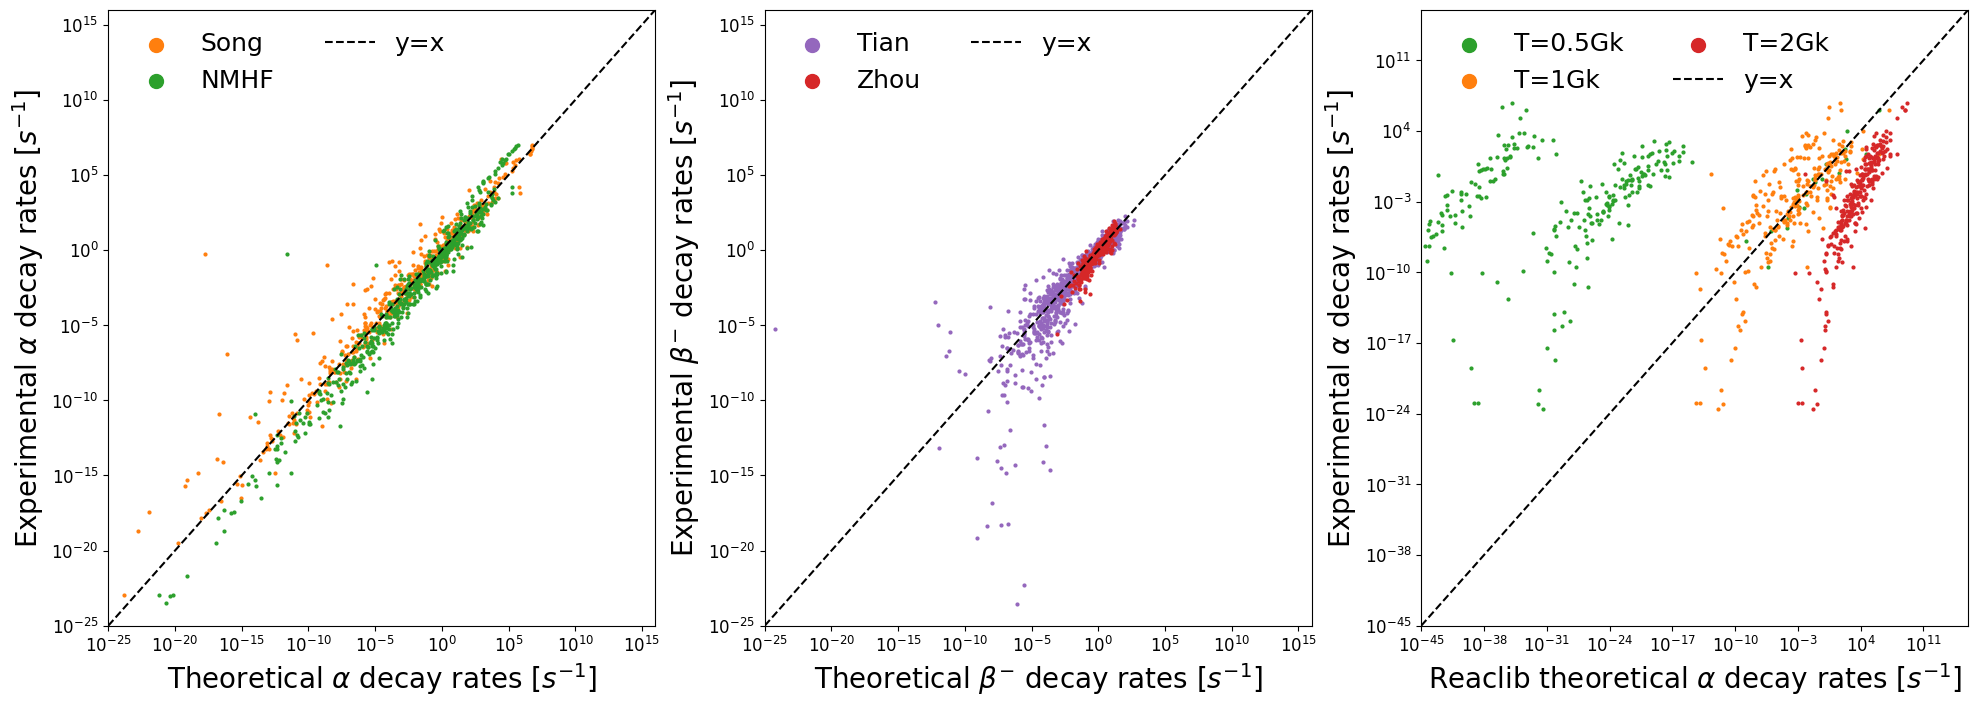

In [13]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 20,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(1,3, figsize=(24,8))

ax[0].set_xlabel(r"Theoretical $\alpha$ decay rates $[s^{-1}]$")
ax[0].set_ylabel(r"Experimental $\alpha$ decay rates $[s^{-1}]$")

ax[0].scatter([r.eval(1e9) for r in song_rates],
            [r.eval(1e9) for r in exp_song_rates],
           color="C1",label="Song",s=4)

ax[0].scatter([r.eval(1e9) for r in NMHF2021_rates],
           [r.eval(1e9) for r in exp_NMHF2021_rates],
           color="C2",label="NMHF",s=4)

ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].plot([1e-25,1e16],[1e-25,1e16],color="k",ls="--",label="y=x")
ax[0].set_xlim(1e-25,1e16)
ax[0].set_ylim(1e-25,1e16)
ax[0].legend(frameon=False, loc="upper left",fontsize=18, ncol=2, markerscale=5)

ax[1].set_xlabel(r"Theoretical $\beta^{-}$ decay rates $[s^{-1}]$")
ax[1].set_ylabel(r"Experimental $\beta^{-}$ decay rates $[s^{-1}]$")


ax[1].scatter([r.eval(1e9) for r in Tian_rates],
           [r.eval(1e9) for r in exp_tian_rates],
           color="C4",label="Tian",s=4)

ax[1].scatter([r.eval(1e9) for r in Zhou_rates],
           [r.eval(1e9) for r in exp_zhou_rates],
           color="C3",label="Zhou",s=4)

ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].plot([1e-25,1e16],[1e-25,1e16],color="k",ls="--",label="y=x")
ax[1].set_xlim(1e-25,1e16)
ax[1].set_ylim(1e-25,1e16)
ax[1].legend(frameon=False, loc="upper left",fontsize=18, ncol=2, markerscale=5)


ax[2].set_xlabel(r"Reaclib theoretical $\alpha$ decay rates $[s^{-1}]$")
ax[2].set_ylabel(r"Experimental $\alpha$ decay rates $[s^{-1}]$")

ax[2].scatter([r.eval(5e8) for r in Alpha_rates_pairs[1]],
           [r.eval(5e8) for r in Alpha_rates_pairs[0]],
           color="C2",label="T=0.5Gk",s=4)

ax[2].scatter([r.eval(1e9) for r in Alpha_rates_pairs[1]],
           [r.eval(1e9) for r in Alpha_rates_pairs[0]],
           color="C1",label="T=1Gk",s=4)

ax[2].scatter([r.eval(2e9) for r in Alpha_rates_pairs[1]],
           [r.eval(2e9) for r in Alpha_rates_pairs[0]],
           color="C3",label="T=2Gk",s=4)
ax[2].set_yscale("log")
ax[2].set_xscale("log")
ax[2].plot([1e-45,1e16],[1e-45,1e16],color="k",ls="--",label="y=x")

ax[2].set_xlim(1e-45,1e16)
ax[2].set_ylim(1e-45,1e16)
ax[2].legend(frameon=False, loc="upper left",fontsize=18, ncol=2, markerscale=5)

fig.savefig("Figure_2_Comparison_decay_rates_with_experiments.pdf")

Figure 3. rangos de las formulas empiricas

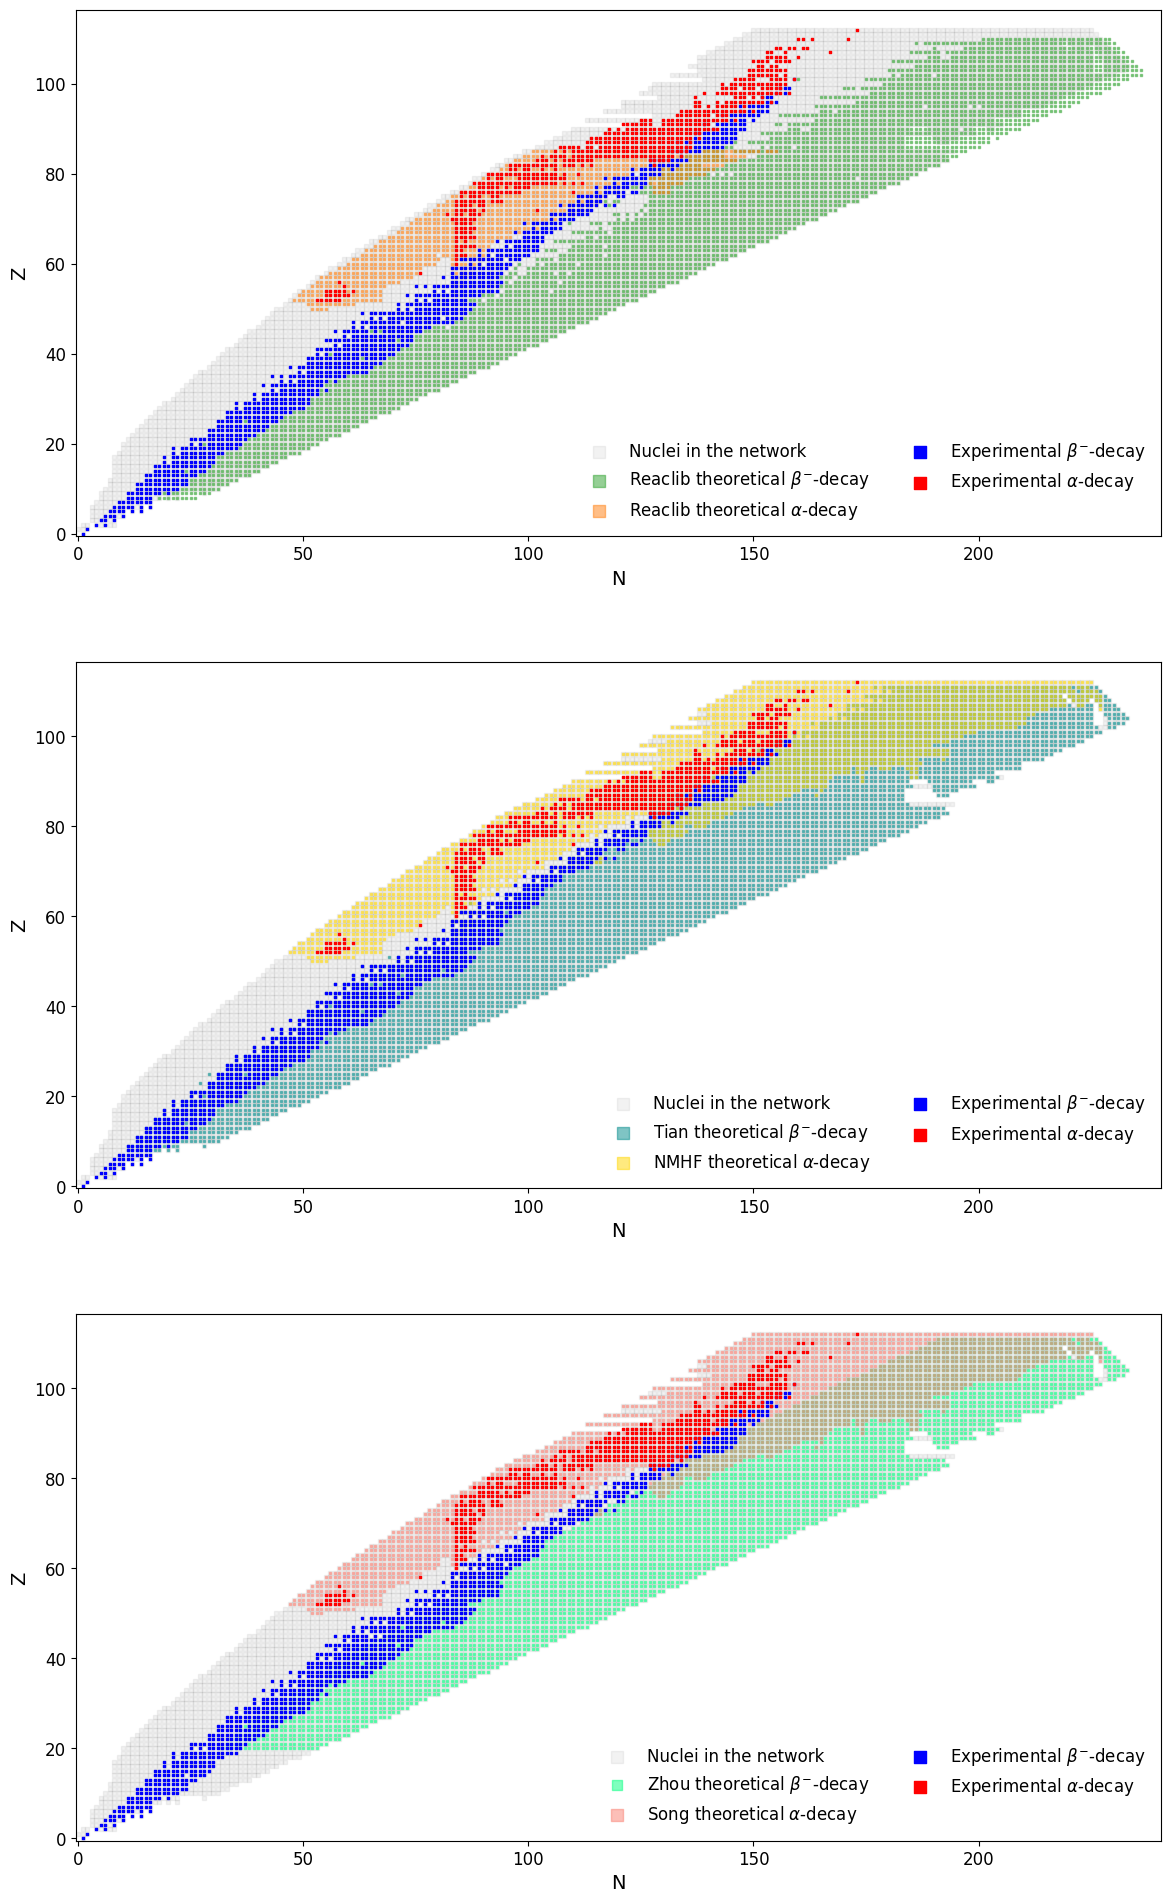

In [11]:
nuclei_in_the_reaction=pd.read_csv(r'Nuclear_Data/Original_files/winvne_v2.0.dat',skiprows=lambda x: not (x>7854 and (x-7855)%4==0),delim_whitespace=True,names=['name','A','Z','N','spin','Mass excess (Mev)','source'])

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(3,1,figsize=(14,24))

ax[0].set_xlabel("N")
ax[0].set_ylabel("Z")
ax[0].set_xlim(-0.5, 240.5)
ax[0].set_ylim(-0.5, 116.5)
ax[0].set_aspect("equal")
ax[0].scatter(nuclei_in_the_reaction['N'],
           nuclei_in_the_reaction['Z'],
           marker='s',color='gray',label='Nuclei in the network',alpha=0.1,s=5)

ax[0].scatter([r.reactants[0].N for r in Beta_minus_rates_theo.get_rates()],
           [r.reactants[0].Z for r in Beta_minus_rates_theo.get_rates()],
           marker="s", color="C2", label=r"Reaclib theoretical $\beta^{-}$-decay",s=4,alpha=0.5)

ax[0].scatter([r.reactants[0].N for r in Alpha_rates_theo.get_rates()],
           [r.reactants[0].Z for r in Alpha_rates_theo.get_rates()],
            marker="s", color="C1", label=r"Reaclib theoretical $\alpha$-decay",s=4,alpha=0.5)


ax[0].scatter([r.reactants[0].N for r in Beta_minus_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Beta_minus_rates_exp.get_rates()],
           marker="s", color="blue", label=r"Experimental $\beta^{-}$-decay",s=4)

ax[0].scatter([r.reactants[0].N for r in Alpha_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Alpha_rates_exp.get_rates()],
           marker="s", color="red", label=r"Experimental $\alpha$-decay",s=4)
ax[0].legend(frameon=False, loc="lower right",fontsize=12, ncol=2,markerscale=4)

ax[1].set_xlabel("N")
ax[1].set_ylabel("Z")
ax[1].set_xlim(-0.5, 240.5)
ax[1].set_ylim(-0.5, 116.5)
ax[1].set_aspect("equal")

ax[1].scatter(nuclei_in_the_reaction['N'],
           nuclei_in_the_reaction['Z'],
           marker='s',color='gray',label='Nuclei in the network',alpha=0.1,s=5)

ax[1].scatter([r.reactants[0].N for r in rates_tian.get_rates()],
           [r.reactants[0].Z for r in rates_tian.get_rates()],
           marker="s", color="darkcyan", label=r"Tian theoretical $\beta^{-}$-decay",s=4,alpha=0.5)

ax[1].scatter([r.reactants[0].N for r in rates_NMHF.get_rates()],
           [r.reactants[0].Z for r in rates_NMHF.get_rates()],
            marker="s", color="gold", label=r"NMHF theoretical $\alpha$-decay",s=4,alpha=0.5)

ax[1].scatter([r.reactants[0].N for r in Beta_minus_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Beta_minus_rates_exp.get_rates()],
           marker="s", color="blue", label=r"Experimental $\beta^{-}$-decay",s=4)

ax[1].scatter([r.reactants[0].N for r in Alpha_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Alpha_rates_exp.get_rates()],
           marker="s", color="red", label=r"Experimental $\alpha$-decay",s=4)
ax[1].legend(frameon=False, loc="lower right",fontsize=12, ncol=2,markerscale=4)


ax[2].set_xlabel("N")
ax[2].set_ylabel("Z")
ax[2].set_xlim(-0.5, 240.5)
ax[2].set_ylim(-0.5, 116.5)
ax[2].set_aspect("equal")
ax[2].scatter(nuclei_in_the_reaction['N'],
           nuclei_in_the_reaction['Z'],
           marker='s',color='gray',label='Nuclei in the network',alpha=0.1,s=5)

ax[2].scatter([r.reactants[0].N for r in rates_zhou.get_rates()],
           [r.reactants[0].Z for r in rates_zhou.get_rates()],
           marker="s", color="springgreen", label=r"Zhou theoretical $\beta^{-}$-decay",s=3,alpha=0.5)
ax[2].scatter([r.reactants[0].N for r in rates_song.get_rates()],
           [r.reactants[0].Z for r in rates_song.get_rates()],
            marker="s", color="salmon", label=r"Song theoretical $\alpha$-decay",s=4,alpha=0.5)

ax[2].scatter([r.reactants[0].N for r in Beta_minus_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Beta_minus_rates_exp.get_rates()],
           marker="s", color="blue", label=r"Experimental $\beta^{-}$-decay",s=4)

ax[2].scatter([r.reactants[0].N for r in Alpha_rates_exp.get_rates()],
           [r.reactants[0].Z for r in Alpha_rates_exp.get_rates()],
           marker="s", color="red", label=r"Experimental $\alpha$-decay",s=4)
ax[2].legend(frameon=False, loc="lower right",fontsize=12, ncol=2,markerscale=4)


fig.savefig("Figure_3_ranges.pdf")